# CCO13: Jie

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad

In [2]:
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO13"
DATA_DIR = "/home/herbert/PyProjects/cocultured_organ/data/260402"

In [3]:
os.system(f"mkdir -p {WORK_DIR}")

0

# 0. Data

In [29]:
os.system(f"mkdir -p {WORK_DIR}/adata/raw")

0

In [120]:
os.system(f"ls -l {DATA_DIR}/*.h5")

-rw-r--r-- 1 herbert yachilab 21022207 Jul 28 09:34 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-AFENC8-JJ-022626-R.h5
-rw-r--r-- 1 herbert yachilab  3825822 Jul 28 09:46 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-AFEWTC-JJ-022626-B.h5
-rw-r--r-- 1 herbert yachilab  6943525 Jul 28 09:46 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-IPSNC8-JJ-022626-G.h5
-rw-r--r-- 1 herbert yachilab  2735413 Jul 28 09:47 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-IPSWTC-JJ-022626-Y.h5


0

In [131]:
adata_all = None

for f in glob.glob(f"{DATA_DIR}/*.h5"):
    batch = f.split("/")[-1].split("-")[0]
    cell_line = f.split("/")[-1].split("-")[1]

    adata = sc.read_10x_h5(f)
    adata.var_names_make_unique()
    adata.obs["batch"] = batch
    adata.obs["cell_line"] = cell_line
    
    if adata_all is None:
        adata_all = adata
    else:
        adata_all = ad.concat([adata_all, adata])

adata_all.write(f"{WORK_DIR}/adata/raw/ALL.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarn

# 1. preprocessing

## 1.1

In [44]:
os.system(f"mkdir -p {WORK_DIR}/adata/processed")

0

In [45]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/raw/ALL.h5ad")

In [46]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True)

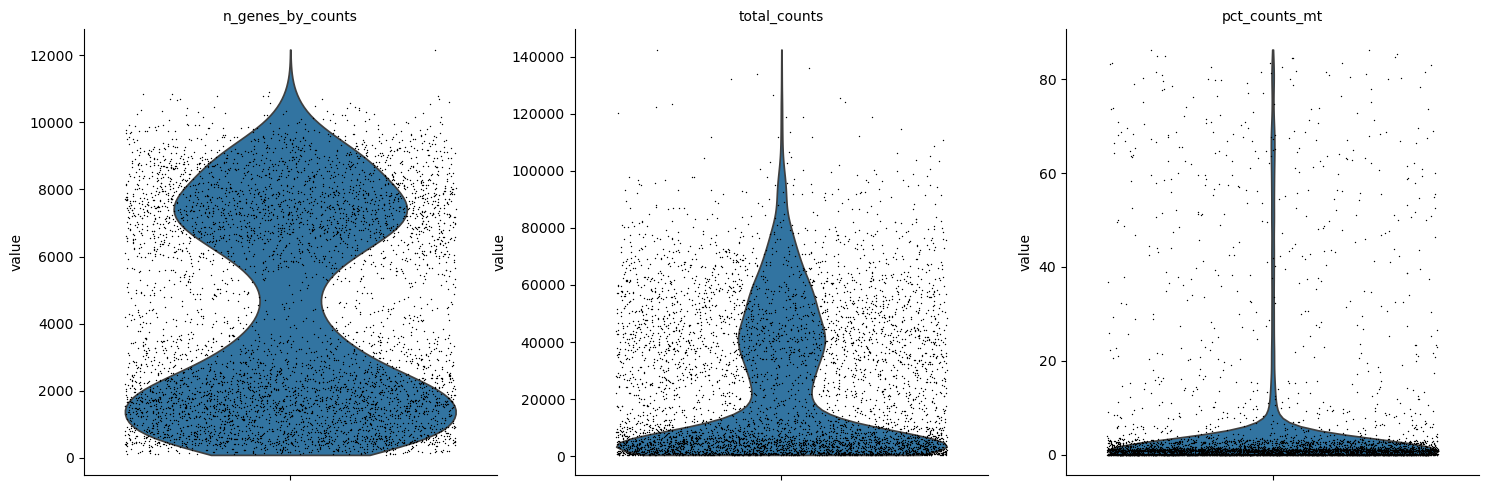

In [47]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

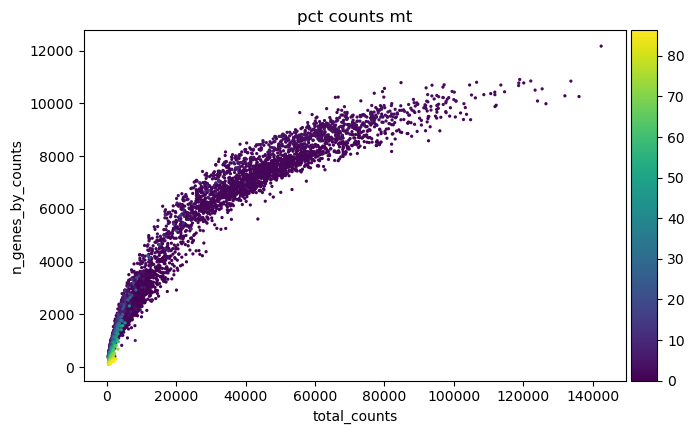

In [48]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [49]:
n_old = adata.n_obs

adata = adata[adata.obs["pct_counts_mt"] < 5]
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print(f"removed due to mito percent or count: {n_old - adata.n_obs}")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


removed due to mito percent or count: 595


In [50]:
n_old = adata.n_obs

sc.external.pp.scrublet(adata, batch_key="batch", random_state=42)
adata = adata[np.logical_not(adata.obs["predicted_doublet"])]

print(f"removed due to doublet: {n_old - adata.n_obs}")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Automatically set threshold at doublet score = 0.44
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 11.8%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
removed due to doublet: 0


In [51]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [52]:
sc.tl.pca(adata, n_comps=100, random_state=42, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=1000, n_pcs=100, random_state=42)
sc.tl.leiden(adata, resolution=0.5, random_state=42)
sc.tl.umap(adata, random_state=42)

In [53]:
adata.obs = adata.obs[["batch", "cell_line", "leiden"]]

In [54]:
adata.write(f"{WORK_DIR}/adata/processed/ALL.h5ad")

## 1.2 visualization

In [55]:
os.system(f"mkdir -p {WORK_DIR}/visual")

0

In [56]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/processed/ALL.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


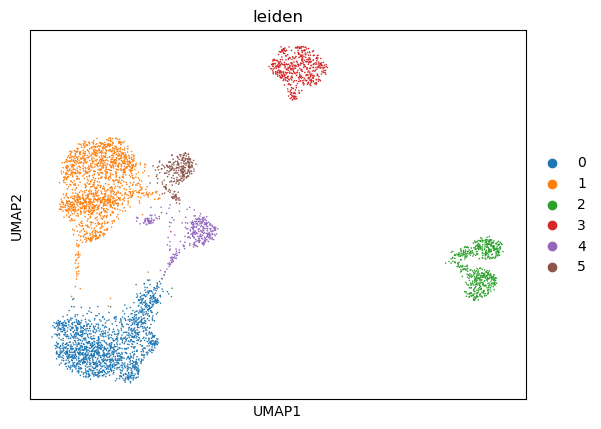

In [57]:
sc.pl.umap(adata, color="leiden", s=5, show=False)
plt.savefig(f"{WORK_DIR}/visual/UMAP.leiden.png", bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


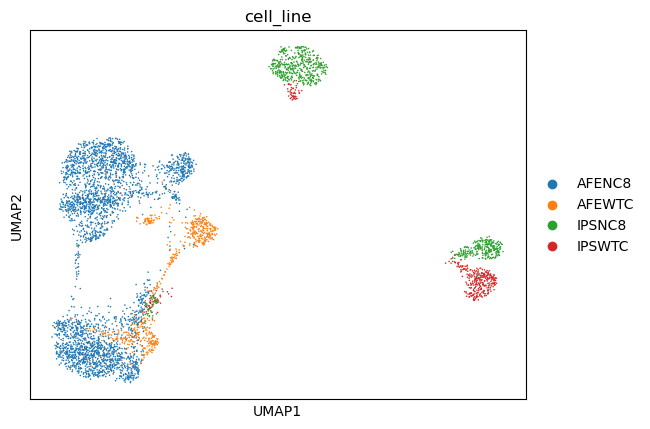

In [58]:
sc.pl.umap(adata, color="cell_line", s=5, show=False)
plt.savefig(f"{WORK_DIR}/visual/UMAP.cell_line.png", bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


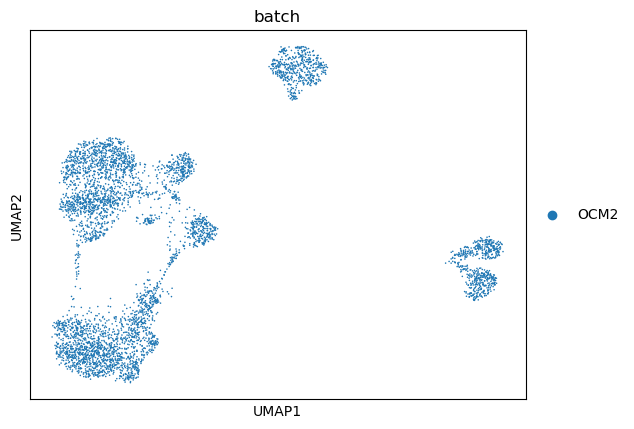

In [59]:
sc.pl.umap(adata, color="batch", s=5)

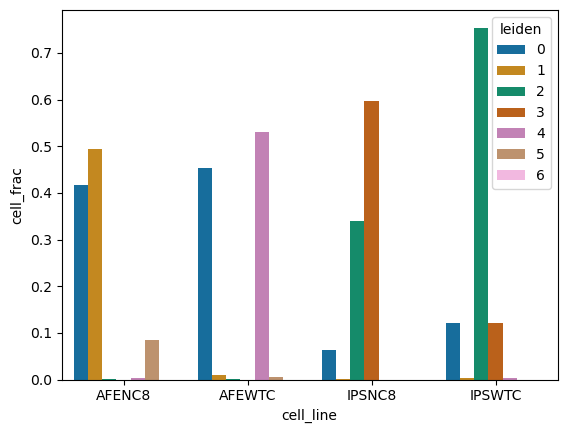

In [60]:
import seaborn as sns

df = adata.obs[["leiden", "cell_line"]].copy()
df["leiden"] = df["leiden"].astype(int)
df["cell_line"] = df["cell_line"].astype(str)

df_plt = {"cell_line": [], "leiden": [], "cell_count": []}

for cl in ("AFENC8", "AFEWTC", "IPSNC8", "IPSWTC"):
    df_sub = df[df["cell_line"] == cl]
    for l in range(0, 7):
        try:
            n = df_sub.leiden.value_counts()[l]
        except:
            n = 0
        df_plt["cell_line"].append(cl)
        df_plt["leiden"].append(l)
        df_plt["cell_count"].append(n)

df_plt = pd.DataFrame(df_plt)
df_plt["cell_frac"] = 0
for i in range(0, df_plt.shape[0]):
    df_plt.iloc[i, 3] = df_plt.iloc[i, 2] / df_plt[df_plt["cell_line"] == df_plt.iloc[i,0]]["cell_count"].sum()
sns.barplot(df_plt, y="cell_frac", x="cell_line", hue="leiden", palette="colorblind")

plt.savefig(f"{WORK_DIR}/visual/cell_fraction.cell_line.png", bbox_inches="tight")
plt.show()

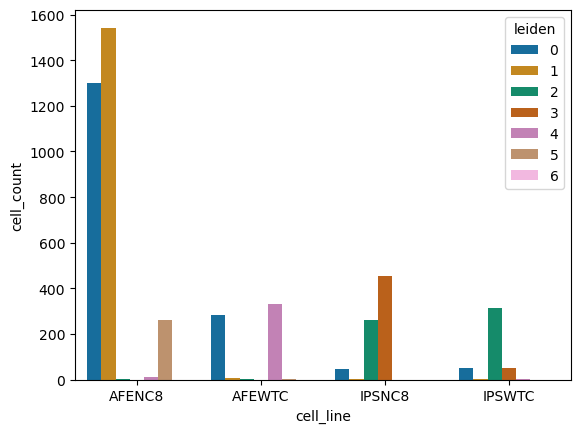

In [61]:
sns.barplot(df_plt, y="cell_count", x="cell_line", hue="leiden", palette="colorblind")
plt.savefig(f"{WORK_DIR}/visual/cell_count.cell_line.png", bbox_inches="tight")
plt.show()

# 2. DE

In [20]:
os.system(f"mkdir -p {WORK_DIR}/DE")

0

In [62]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/processed/ALL.h5ad")

In [65]:
def volcano_plot1(adata, 
                  label1, 
                  label2, 
                  title=None, 
                  label_type='leiden', 
                  keygenes=None, 
                  save=None, 
                  save_tsv=None,
                  log2fc=1, 
                  min_mean=0.1,
                  xlim=None,
                  ylim=None,
                  log_y_axis=False,
                  s=1,
                  y0_ref_line=False,
                 ):
    
    PSEUDOCOUNT=0.0001
    
    if label1 == "all":
        data1 = adata.X.todense().copy() + PSEUDOCOUNT
    elif label1 == "rest":
        data1 = adata.X[np.where(adata.obs[label_type] != label2)[0], :].todense().copy() + PSEUDOCOUNT
    else:
        data1 = adata.X[np.where(adata.obs[label_type] == label1)[0], :].todense().copy() + PSEUDOCOUNT
        
    if label2 == "all":
        data2 = adata.X.todense().copy() + PSEUDOCOUNT
    elif label2 == "rest":
        data2 = adata.X[np.where(adata.obs[label_type] != label1)[0], :].todense().copy() + PSEUDOCOUNT
    else:
        data2 = adata.X[np.where(adata.obs[label_type] == label2)[0], :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.squeeze(np.asarray(np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )))

    means = np.squeeze(np.asarray(np.mean(np.concatenate((data1, data2), axis=0), axis=0)))

    idx_inc = [i for i in range(0, len(foldchanges)) if (foldchanges[i] >= log2fc and means[i] > min_mean)]
    idx_dec = [i for i in range(0, len(foldchanges)) if (foldchanges[i] <= -1*log2fc and means[i] > min_mean)]

    plt.scatter(foldchanges, 
                means, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                means[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_dec], 
                means[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s)
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], means[gene_idx], keygene, ha='center', va='center')
            
    if y0_ref_line:
        plt.axvline(0, linestyle="--")

    plt.xlabel('Log2FC')
    plt.ylabel('mean')
    if title is not None:
        plt.title(title)
    plt.legend()
    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)
        
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata.var_names.to_list()
        de_dict[label1] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict[label2] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['significant'] = [0 if (i not in idx_inc and i not in idx_dec) else 1 for i in range(len(means))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t', index=False)
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t', index=False)

        if keygenes is not None and len(keygenes) > 0:
            df[df['gene'].isin(keygenes)].to_csv(f"{(save_tsv).strip('.tsv')}.marker.tsv", sep='\t')

In [68]:
for i in range(0, 7):
    volcano_plot1(
        adata, 
        label1="rest", 
        label2=str(i), 
        # xlim=(-10, 10), 
        ylim=(0, 5.5),
        log2fc=1, 
        min_mean=0.5,
        save=f"{WORK_DIR}/DE/leiden.{i}.png",
        save_tsv=f"{WORK_DIR}/DE/leiden.{i}.tsv",
        y0_ref_line=True
    )

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/numpy/matrixlib/defmatrix.py:445: RuntimeWarning: Mean of empty slice.
  return N.ndarray.mean(self, axis, dtype, out, keepdims=True)._collapse(axis)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/numpy/core/_methods.py:181: RuntimeWarning: invalid value encountered in true_divide
  ret = um.true_divide(
